In [1]:
import numpy as np

In [2]:
from gaussian_systems.initial_state import GaussianCVState

In [3]:
n = 2 # system size
kappa = 1 # normalized decay rate

n_mode_state = GaussianCVState.vacuum(2)
n_mode_state.single_mode_squeeze((0.5, 0.0), 1)
base_state = n_mode_state.copy_state().single_mode_squeeze((0.5, 0.0), 2)

In [4]:
from gaussian_systems.systems import GaussianCVSystem

In [5]:
mode_frequencies = np.array([2.0*kappa,2.0*kappa]) #both modes have frequency of 2&kappa
n_mode_free_system = GaussianCVSystem.free_evolution(n, mode_frequencies)

base_system = n_mode_free_system.copy_system().multi_annihilation_dissipator(
    subsystem=(1,2),
    decay=kappa,
)

In [6]:
t_eval = np.linspace(0,10,1000)

base_solution = base_system.evolve_state(base_state,t_eval)

In [7]:
base_entanglement = base_solution.entanglement_time_trace((1,2))
base_purity = base_solution.purity_time_trace((1,2))

In [18]:
misaligned_state = n_mode_state.copy_state().single_mode_squeeze((0.5,np.pi/2), 2)

t_eval = np.linspace(0,10,1000)

misaligned_solution = base_system.evolve_state(misaligned_state,t_eval)

misaligned_entanglement = misaligned_solution.entanglement_time_trace((1,2))
misaligned_purity = misaligned_solution.purity_time_trace((1,2))

In [19]:
orthogonal_state = n_mode_state.copy_state().single_mode_squeeze((0.5,np.pi), 2)

t_eval = np.linspace(0,10,1000)

orthogonal_solution = base_system.evolve_state(orthogonal_state,t_eval)

orthogonal_entanglement = orthogonal_solution.entanglement_time_trace((1,2))
orthogonal_purity = orthogonal_solution.purity_time_trace((1,2))

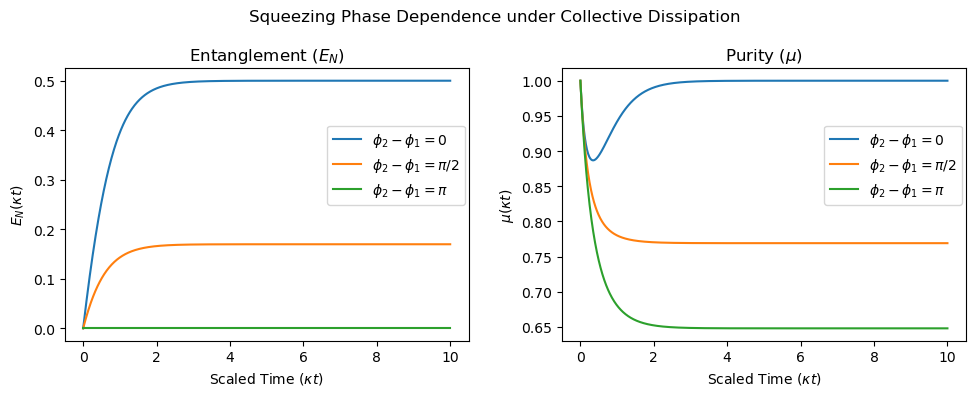

In [29]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].plot(t_eval, base_entanglement, label=r"$\phi_2 - \phi_1 = 0$")
axes[0].plot(t_eval, misaligned_entanglement, label=r"$\phi_2 - \phi_1 = \pi/2$")
axes[0].plot(t_eval, orthogonal_entanglement, label=r"$\phi_2 - \phi_1 = \pi$")
axes[0].set_title(r"Entanglement ($E_N$)")
axes[0].set_ylabel(r"$E_N(\kappa t)$")
axes[1].plot(t_eval, base_purity, label=r"$\phi_2 - \phi_1 = 0$")
axes[1].plot(t_eval, misaligned_purity, label=r"$\phi_2 - \phi_1 = \pi/2$")
axes[1].plot(t_eval, orthogonal_purity, label=r"$\phi_2 - \phi_1 = \pi$")
axes[1].set_title(r"Purity ($\mu$)")
axes[1].set_ylabel(r"$\mu(\kappa t)$")
for ax in axes:
    ax.set_xlabel(r"Scaled Time $(\kappa t)$")
axes[0].legend(loc=(0.65, 0.5))
axes[1].legend(loc=(0.65, 0.5))
fig.suptitle("Squeezing Phase Dependence under Collective Dissipation")
plt.tight_layout()
plt.show()